# Retail supplier warehouse: the numbers

Every number in the README, on the portfolio card and in `powerbi/06-checks.md` comes from this notebook.
It reads the finished star schema (`marts`) with plain SQL, so the same queries can check the Power BI report.
Every client value (name, currency, colours, the late rule, the number of top sellers, the check year) comes from `config/client.yaml` through `load_config()`.

**Run it after** `docker compose up -d` and one run of the `retail_warehouse` DAG.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import psycopg

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))
from config import load_config

cfg = load_config()
NAME, CURRENCY, DECIMALS = cfg["client"]["name"], cfg["client"]["currency"], cfg["client"]["decimals"]
LATE_AFTER, TOP_N = cfg["rules"]["late_after_days"], cfg["rules"]["top_sellers"]
CHECK_YEAR, MIN_STATE_ITEMS = cfg["report"]["check_year"], cfg["report"]["min_state_items"]
ACCENT, GREY = cfg["report"]["colours"]["data"][0], cfg["report"]["colours"]["muted"]
# Charts use the README's navy and teal look; the Power BI theme keeps client.yaml's colours.
ACCENT, GREY, TEXT = "#2DD4BF", "#94A3B8", "#E2E8F0"
plt.rcParams.update({"figure.facecolor": "#0F172A", "axes.facecolor": "#0F172A", "savefig.facecolor": "#0F172A",
                     "text.color": TEXT, "axes.labelcolor": TEXT, "axes.titlecolor": TEXT, "xtick.color": TEXT,
                     "ytick.color": TEXT, "legend.labelcolor": TEXT, "axes.edgecolor": "#334155", "grid.color": "#334155"})
CHARTS = ROOT / "docs" / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)
conn = psycopg.connect(cfg["db_url"])

def q(sql, params=None):
    """Run a query and return a DataFrame."""
    with conn.cursor() as cur:
        cur.execute(sql, params)
        return pd.DataFrame(cur.fetchall(), columns=[c.name for c in cur.description])

def money(value):
    return f"{CURRENCY} {value:,.{DECIMALS}f}"

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
numbers = {}  # every headline number, collected for the summary at the end
print(NAME, "|", CURRENCY, "| late after", LATE_AFTER, "days | top", TOP_N, "sellers")

Sample online store | BRL | late after 0 days | top 100 sellers


## 1. What was loaded

`raw.load_log` keeps the row count of every load. The fact table is built from order items, so an order without items (often canceled) stays in `raw.orders` but not in the fact.

In [2]:
loaded = q("""
    select distinct on (table_name) table_name, source_file, rows_loaded, loaded_at
    from raw.load_log
    order by table_name, loaded_at desc""")
star = q("""
    select count(distinct order_id) as orders,
           count(*)                 as order_items,
           count(distinct seller_id) as sellers_with_sales,
           count(distinct product_id) as products_sold,
           (select count(distinct department) from marts.dim_product) as departments,
           min(order_date) as first_order, max(order_date) as last_order
    from marts.fact_order_items""")
numbers["orders loaded"] = int(loaded.set_index("table_name").rows_loaded["orders"])
numbers["orders in the fact table"] = int(star.orders[0])
numbers["order items"] = int(star.order_items[0])
numbers["sellers"] = int(q("select count(*) as n from marts.dim_seller").n[0])
numbers["departments"] = int(star.departments[0])
display(loaded)
star

,table_name,source_file,rows_loaded,loaded_at
0,customers,olist_customers_dataset.csv,99441,2026-10-05 13:55:21.136236+00:00
1,departments,departments.csv,73,2026-10-05 13:55:21.136236+00:00
2,order_items,olist_order_items_dataset.csv,112650,2026-10-05 13:55:21.136236+00:00
3,orders,olist_orders_dataset.csv,99441,2026-10-05 13:55:21.136236+00:00
4,products,olist_products_dataset.csv,32951,2026-10-05 13:55:21.136236+00:00
5,reviews,olist_order_reviews_dataset.csv,99224,2026-10-05 13:55:21.136236+00:00
6,sellers,olist_sellers_dataset.csv,3095,2026-10-05 13:55:21.136236+00:00


,orders,order_items,sellers_with_sales,products_sold,departments,first_order,last_order
0,98666,112650,3095,32951,74,2016-09-04,2018-09-03


## 2. Data tests passing

`dbt build` writes `dbt/target/run_results.json` on every run. This counts its data tests by status.

In [3]:
run = json.loads((ROOT / "dbt" / "target" / "run_results.json").read_text())
tests = [r for r in run["results"] if r["unique_id"].startswith("test.")]
status = pd.Series([r["status"] for r in tests]).value_counts()
numbers["data tests passing"] = int(status.get("pass", 0))
numbers["data tests in total"] = len(tests)
print("dbt run finished at", run["metadata"]["generated_at"])
status

dbt run finished at 2026-10-05T13:57:44.309335Z


pass    31
Name: count, dtype: int64

## 3. How often deliveries are late

**Late** = the order was delivered (status `delivered` with a delivery date) more than `rules.late_after_days` days after the date promised to the customer.
Orders are counted once; items are counted per row, because one order can hold items from different sellers.

In [4]:
late = q("""
    select count(distinct order_id) filter (where is_delivered) as delivered_orders,
           count(distinct order_id) filter (where is_late)      as late_orders,
           count(*) filter (where is_delivered)                 as delivered_items,
           count(*) filter (where is_late)                      as late_items
    from marts.fact_order_items""").iloc[0]
numbers["delivered orders"] = int(late.delivered_orders)
numbers["late orders"] = int(late.late_orders)
numbers["late order rate"] = late.late_orders / late.delivered_orders
numbers["delivered items"] = int(late.delivered_items)
numbers["late items"] = int(late.late_items)
numbers["late item rate"] = late.late_items / late.delivered_items
print(f"Late: delivered more than {LATE_AFTER} day(s) after the promised date")
late

Late: delivered more than 0 day(s) after the promised date


delivered_orders     96470
late_orders           6534
delivered_items     110189
late_items            7264
Name: 0, dtype: int64

## 4. Which sellers cause the late deliveries

Sellers are the store's suppliers. `dim_seller.late_rank` orders them by late items (ties broken by `seller_id`); the first `rules.top_sellers` are the **top sellers**, the same flag Power BI uses.
To be fair, compare their share of late items with their share of all delivered items: big sellers are expected to have more late items simply because they ship more.

In [5]:
sellers = q("""
    select s.seller_id, s.state, s.late_rank, s.is_top_late_seller,
           count(*) filter (where f.is_delivered) as delivered_items,
           count(*) filter (where f.is_late)      as late_items
    from marts.dim_seller s
    left join marts.fact_order_items f using (seller_id)
    group by s.seller_id, s.state, s.late_rank, s.is_top_late_seller""")
top = sellers[sellers.is_top_late_seller]
rest = sellers[~sellers.is_top_late_seller]
numbers["top sellers"] = len(top)
numbers["top sellers: share of late items"] = top.late_items.sum() / sellers.late_items.sum()
numbers["top sellers: share of delivered items"] = top.delivered_items.sum() / sellers.delivered_items.sum()
numbers["top sellers: late item rate"] = top.late_items.sum() / top.delivered_items.sum()
numbers["other sellers: late item rate"] = rest.late_items.sum() / rest.delivered_items.sum() if rest.delivered_items.sum() else 0.0
numbers["sellers with at least one late item"] = int((sellers.late_items > 0).sum())
sellers.sort_values("late_rank").head(3)

,seller_id,state,late_rank,is_top_late_seller,delivered_items,late_items
1888,4a3ca9315b744ce9f8e9374361493884,SP,1,True,1949,189
304,1f50f920176fa81dab994f9023523100,SP,2,True,1926,150
732,4869f7a5dfa277a7dca6462dcf3b52b2,SP,3,True,1148,121


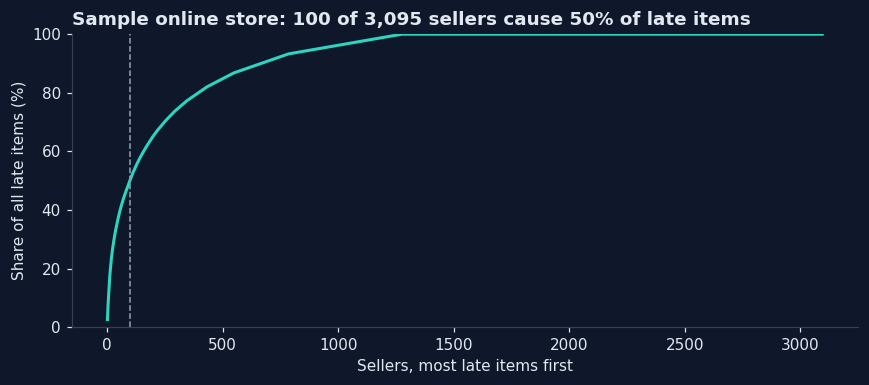

In [6]:
ranked = sellers.sort_values("late_rank").reset_index(drop=True)
cum = ranked.late_items.cumsum() / ranked.late_items.sum()
share = numbers["top sellers: share of late items"] * 100
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(range(1, len(cum) + 1), cum * 100, color=ACCENT, lw=2)
ax.axvline(TOP_N, color=GREY, ls="--", lw=1)
ax.set_xlabel("Sellers, most late items first")
ax.set_ylabel("Share of all late items (%)")
ax.set_title(f"{NAME}: {TOP_N} of {len(sellers):,} sellers cause {share:.0f}% of late items", loc="left", fontweight="bold")
ax.set_ylim(0, 100)
fig.tight_layout()
fig.savefig(CHARTS / "late-items-by-seller.png", dpi=150)
plt.show()

## 5. Late deliveries cost reviews

Average review score (1 to 5) per order, each reviewed order counted once, late against on time. When an order was reviewed twice, the latest review counts.

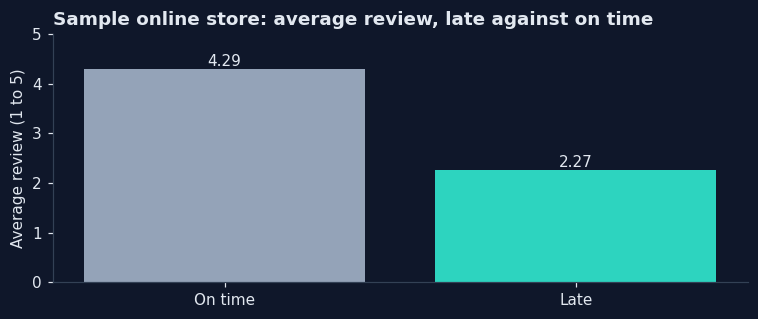

,average_review,reviewed_orders
delivery,,
On time,4.29,89443
Late,2.27,6381


In [7]:
reviews = q("""
    select case when is_late then 'Late' else 'On time' end as delivery,
           avg(review_score)::numeric(4, 2) as average_review,
           count(*) as reviewed_orders
    from (select distinct order_id, is_late, review_score
          from marts.fact_order_items
          where is_delivered and review_score is not null) o
    group by 1 order by 1 desc""").set_index("delivery")
numbers["average review, on time"] = float(reviews.average_review.get("On time", float("nan")))
numbers["average review, late"] = float(reviews.average_review.get("Late", float("nan")))
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(reviews.index, reviews.average_review.astype(float), color=[GREY if d == "On time" else ACCENT for d in reviews.index])
ax.bar_label(bars, fmt="%.2f")
ax.set_ylim(0, 5)
ax.set_ylabel("Average review (1 to 5)")
ax.set_title(f"{NAME}: average review, late against on time", loc="left", fontweight="bold")
fig.tight_layout()
fig.savefig(CHARTS / "review-late-vs-on-time.png", dpi=150)
plt.show()
reviews

## 6. Late rate by department

The ten departments with the most delivered items.

In [8]:
departments = q("""
    select p.department,
           count(*) filter (where f.is_delivered) as delivered_items,
           count(*) filter (where f.is_late)      as late_items,
           round(100.0 * count(*) filter (where f.is_late) / nullif(count(*) filter (where f.is_delivered), 0), 1) as late_rate_pct
    from marts.fact_order_items f
    join marts.dim_product p using (product_id)
    group by p.department
    order by delivered_items desc
    limit 10""")
departments

,department,delivered_items,late_items,late_rate_pct
0,bed bath table,10953,770,7.0
1,health beauty,9465,716,7.6
2,sports leisure,8430,532,6.3
3,furniture decor,8160,574,7.0
4,computers accessories,7643,496,6.5
5,housewares,6795,340,5.0
6,watches gifts,5857,422,7.2
7,telephony,4430,308,7.0
8,garden tools,4268,280,6.6
9,auto,4139,291,7.0


## 7. Sales

Sales are item prices without freight, over all orders whatever their status: the same as the Power BI `Sales` measure. The monthly chart leaves out the last month when the data ends before that month does.

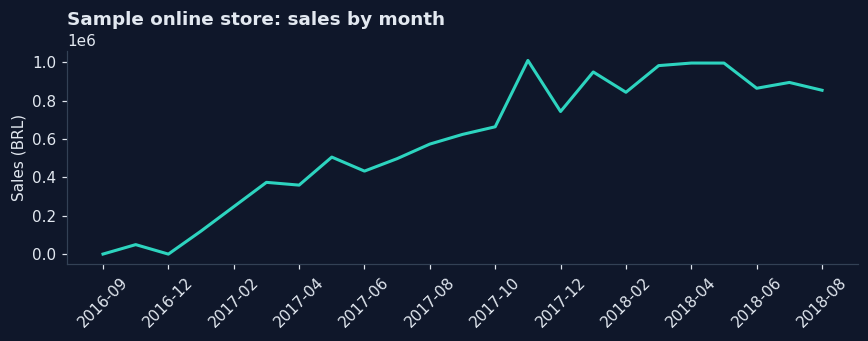

Sales BRL 13,591,643.70 | freight BRL 2,251,909.54


In [9]:
sales = q("""
    select sum(price) as sales, sum(freight) as freight,
           count(distinct order_id) as orders,
           sum(price) / count(distinct order_id) as average_order_value
    from marts.fact_order_items""").iloc[0]
numbers["sales"] = float(sales.sales)
numbers["freight"] = float(sales.freight)
numbers["freight % of sales"] = float(sales.freight / sales.sales)
numbers["average order value"] = float(sales.average_order_value)
numbers["average delivery days"] = float(q("""
    select avg(delivery_days)::numeric(5, 1) as d
    from (select distinct order_id, delivery_days from marts.fact_order_items where is_delivered) o""").d[0])
numbers["average review, all orders"] = float(q("""
    select avg(review_score)::numeric(4, 2) as r
    from (select distinct order_id, review_score from marts.fact_order_items where review_score is not null) o""").r[0])

monthly = q("""
    select d.year_month, sum(f.price) as sales
    from marts.fact_order_items f join marts.dim_date d on d.date = f.order_date
    where f.order_date < (select case when max(order_date) = (date_trunc('month', max(order_date)) + interval '1 month - 1 day')::date
                                      then max(order_date) + 1
                                      else date_trunc('month', max(order_date))::date end
                          from marts.fact_order_items)
    group by d.year_month order by d.year_month""")
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(monthly.year_month, monthly.sales.astype(float), color=ACCENT, lw=2, marker="o" if len(monthly) < 4 else None)
ax.set_xticks(monthly.year_month[::max(1, len(monthly) // 8)])
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel(f"Sales ({CURRENCY})")
ax.set_title(f"{NAME}: sales by month", loc="left", fontweight="bold")
fig.tight_layout()
fig.savefig(CHARTS / "sales-by-month.png", dpi=150)
plt.show()
print("Sales", money(numbers["sales"]), "| freight", money(numbers["freight"]))

## 8. Power BI check numbers

The numbers `powerbi/06-checks.md` asks for beyond the totals above: the year slicer on `report.check_year`, the first rows of the sellers table, and the state chart with `report.min_state_items`.

In [10]:
year = q("""
    select sum(price) as sales, count(distinct order_id) as orders,
           count(distinct order_id) filter (where is_late)::numeric
             / nullif(count(distinct order_id) filter (where is_delivered), 0) as late_order_rate
    from marts.fact_order_items
    where extract(year from order_date) = %s""", (CHECK_YEAR,)).iloc[0]
numbers[f"{CHECK_YEAR}: sales"] = float(year.sales or 0)
numbers[f"{CHECK_YEAR}: orders"] = int(year.orders)
numbers[f"{CHECK_YEAR}: late order rate"] = float(year.late_order_rate or 0)

states = sellers.groupby("state")[["delivered_items", "late_items"]].sum()
states = states[states.delivered_items >= MIN_STATE_ITEMS]
states["late_item_rate"] = states.late_items / states.delivered_items
print(f"States with at least {MIN_STATE_ITEMS} delivered items, highest late item rate first:")
display(states.sort_values("late_item_rate", ascending=False).head(3))
ranked[["seller_id", "delivered_items", "late_items"]].head(2)

States with at least 500 delivered items, highest late item rate first:


,delivered_items,late_items,late_item_rate
state,,,
SP,78598,5585,0.071058
RJ,4685,324,0.069157
DF,883,53,0.060023


,seller_id,delivered_items,late_items
0,4a3ca9315b744ce9f8e9374361493884,1949,189
1,1f50f920176fa81dab994f9023523100,1926,150


## 9. Summary

The numbers used in the README, on the portfolio card and in `powerbi/06-checks.md`.

In [11]:
def show(name, value):
    if "rate" in name or "share" in name or "%" in name:
        return f"{value:.1%}"
    if name.endswith("sales") or name in ("freight", "average order value"):
        return money(value)
    return f"{value:,.2f}" if isinstance(value, float) else f"{value:,}"

pd.DataFrame({"value": {name: show(name, value) for name, value in numbers.items()}})

,value
orders loaded,"99,441"
orders in the fact table,"98,666"
order items,"112,650"
sellers,"3,095"
departments,74
data tests passing,31
data tests in total,31
delivered orders,"96,470"
late orders,"6,534"
late order rate,6.8%
